In [1]:
%pip install scikit-learn xgboost pyarrow pandas numpy matplotlib seaborn google-cloud-bigquery db_dtypes shap sklearn category_encoders

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

client = bigquery.Client(project='project3grupo1')
print('Conexión OK')

Conexión OK


In [3]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

# Inicializa el cliente
client = bigquery.Client()

# Extraemos solo un 15% de los datos para no saturar la RAM y ahorrar costes de consulta.
# Puedes ajustar este porcentaje según el tamaño total de tu tabla.
query = """
    SELECT *
    FROM `project3grupo1.airbnb_features.datos_modelo_ml_yannis`
    TABLESAMPLE SYSTEM (15 PERCENT)
"""

# create_bqstorage_client=True hace que la descarga sea muchísimo más rápida
print("Descargando datos...")
df= client.query(query).to_dataframe(create_bqstorage_client=True)

print(f"Tamaño original en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Optimización de RAM: Downcasting matemático
for col in df.columns:
    col_type = df[col].dtype
    
    if col_type == 'float64':
        df[col] = df[col].astype('float32')
    elif col_type == 'int64':
        # Convierte al entero más pequeño que pueda contener los datos (int8, int16, int32)
        df[col] = pd.to_numeric(df[col], downcast='integer')

print(f"Tamaño optimizado en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Filas y columnas extraídas: {df.shape}")

# (Opcional) Guardar este subconjunto optimizado en local para no tener que volver a consultar a BigQuery
df.to_parquet('datos_muestra_optimizada.parquet', index=False)

Descargando datos...
Tamaño original en memoria: 100.18 MB
Tamaño optimizado en memoria: 94.74 MB
Filas y columnas extraídas: (356403, 21)


In [4]:
# Busca esta línea en tu notebook y asegúrate de que incluya 'listing_price'
FEATURES = [
    'month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'listing_price', # <--- ¡Añádela aquí!
    'minimum_nights', 'number_of_reviews', 'review_scores_rating', 
    'instant_bookable', 'temp_mean', 'precipitation_mm', 'num_sports', 
    'num_festivals', 'total_attendance'
]

TARGET = 'is_occupied' # Según el README, este es tu objetivo

In [5]:
df[df['temp_mean'].isnull()]['date'].value_counts()

Series([], Name: count, dtype: int64)

In [6]:
df = df[df['temp_mean'].notna()].copy()
print(f'Shape: {df.shape}')

Shape: (356403, 21)


In [7]:
# Ponemos TARGET entre corchetes para que sea una lista de un solo elemento
df = df[[TARGET] + FEATURES].copy()

print(f'Shape: {df.shape}')
print(f'Nulos:\n{df.isnull().sum()}')

Shape: (356403, 19)
Nulos:
is_occupied                   0
month                         0
day_of_week                   0
is_weekend                    0
days_to_next_holiday          0
is_holiday                    0
neighbourhood_cleansed        0
room_type                     0
accommodates                  0
listing_price                 0
minimum_nights                0
number_of_reviews             0
review_scores_rating      67329
instant_bookable              0
temp_mean                     0
precipitation_mm              0
num_sports                    0
num_festivals                 0
total_attendance              0
dtype: int64


In [8]:
%pip install category_encoders


Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Asegúrate de haber instalado: %pip install category_encoders
from category_encoders import TargetEncoder 

# 1. Definir qué columnas son cuáles
num_cols = ['month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
            'accommodates', 'listing_price', 'minimum_nights', 'number_of_reviews',
            'review_scores_rating', 'instant_bookable', 'temp_mean', 'precipitation_mm',
            'num_sports', 'num_festivals', 'total_attendance']

# 2. Crear los pipelines de procesamiento
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# 3. Configurar el preprocesador (usando TargetEncoder para el barrio)
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('neighborhood', TargetEncoder(), ['neighbourhood_cleansed']),
    ('room', OneHotEncoder(drop='first', handle_unknown='ignore'), ['room_type'])
])

print("Preprocesador configurado correctamente")


Preprocesador configurado correctamente


In [10]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test : {X_test.shape}')
print(f'Distribución train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribución test : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train: (285122, 18)
Test : (71281, 18)
Distribución train: {np.int64(0): 0.628, np.int64(1): 0.372}
Distribución test : {np.int64(0): 0.628, np.int64(1): 0.372}


In [11]:
# Para ver qué columnas tienes realmente
print("Columnas disponibles:", X_train.columns.tolist())

# Si 'listing_price' era tu variable objetivo (y), usa:
cap_cols = {
    'listing_price': y_train.quantile(0.99), # Cambia X_train por y_train si es el target
    'accommodates':  X_train['accommodates'].quantile(0.99),
}

X_train = X_train.copy()
X_test  = X_test.copy()

for col, upper in cap_cols.items():
    X_train[col] = X_train[col].clip(upper=upper)
    X_test[col]  = X_test[col].clip(upper=upper)

print('Caps aplicados:')
for col, upper in cap_cols.items():
    print(f'  {col}: upper={upper}')

Columnas disponibles: ['month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'listing_price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'temp_mean', 'precipitation_mm', 'num_sports', 'num_festivals', 'total_attendance']
Caps aplicados:
  listing_price: upper=1.0
  accommodates: upper=12.0


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
            'accommodates', 'listing_price', 'minimum_nights', 'number_of_reviews',
            'review_scores_rating', 'instant_bookable', 'temp_mean', 'precipitation_mm',
            'num_sports', 'num_festivals', 'total_attendance']

cat_cols = ['neighbourhood_cleansed', 'room_type']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,         num_cols),
    ('cat', categorical_pipeline,     cat_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Shape train procesado: {X_train_processed.shape}')
print(f'Shape test procesado : {X_test_processed.shape}')

Shape train procesado: (285122, 87)
Shape test procesado : (71281, 87)


In [13]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scorers = {
    'accuracy':  'accuracy',
    'f1':        make_scorer(f1_score, average='binary', zero_division=0),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall':    make_scorer(recall_score, average='binary', zero_division=0),
    'roc_auc':   'roc_auc',
}

ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"El ratio de desequilibrio es: {ratio:.2f}")


best_model = XGBClassifier(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

cv_res = cross_validate(best_model, X_train_processed, y_train, cv=cv, scoring=scorers)
print(f"F1-Score medio: {cv_res['test_f1'].mean():.4f}")

print(f"Métricas de Validación (CV):")
print(f"  F1-Score: {cv_res['test_f1'].mean():.4f}")
print(f"  AUC-ROC:  {cv_res['test_roc_auc'].mean():.4f}")

best_model.fit(X_train_processed, y_train)
y_pred  = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred, target_names=['libre', 'ocupado'], zero_division=0))




El ratio de desequilibrio es: 1.69
F1-Score medio: 0.7305
Métricas de Validación (CV):
  F1-Score: 0.7305
  AUC-ROC:  0.8634
              precision    recall  f1-score   support

       libre       0.85      0.82      0.84     44733
     ocupado       0.72      0.76      0.74     26548

    accuracy                           0.80     71281
   macro avg       0.79      0.79      0.79     71281
weighted avg       0.80      0.80      0.80     71281



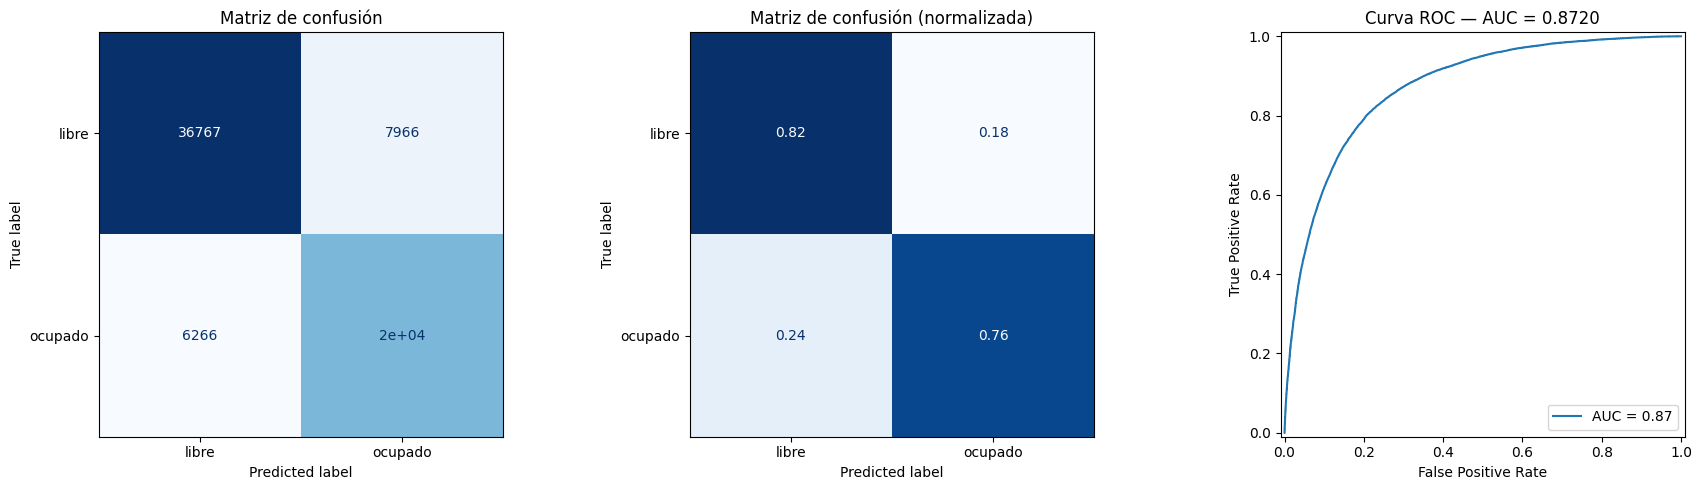

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    colorbar=False, display_labels=['libre', 'ocupado']
)
axes[0].set_title('Matriz de confusión')

# Matriz normalizada
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1], cmap='Blues',
    colorbar=False, normalize='true', display_labels=['libre', 'ocupado']
)
axes[1].set_title('Matriz de confusión (normalizada)')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[2])
axes[2].set_title(f'Curva ROC — AUC = {roc_auc:.4f}')

plt.tight_layout()
plt.show()

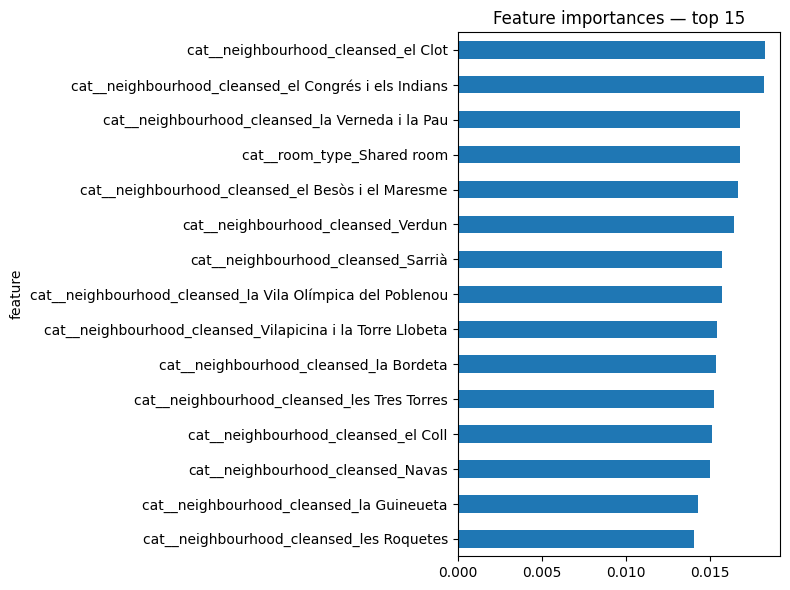

In [15]:
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

fi_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    figsize=(8, 6), title='Feature importances — top 15', legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
!pip install shap

In [17]:
# import shap

# explainer   = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X_test_processed[:5000])

# shap.summary_plot(shap_values, X_test_processed[:5000], feature_names=feature_names)

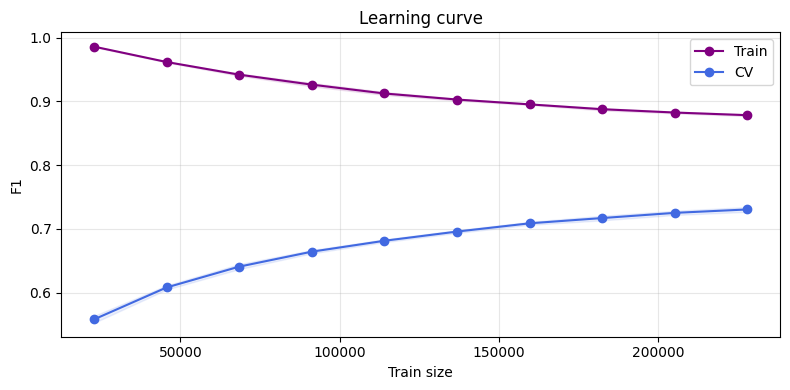

Gap final (F1): 0.1478


In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=42
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tm, 'o-', color='purple',    label='Train')
ax.plot(train_sizes, vm, 'o-', color='royalblue', label='CV')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.1, color='purple')
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.1, color='royalblue')
ax.set(xlabel='Train size', ylabel='F1', title='Learning curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gap final (F1): {tm[-1] - vm[-1]:.4f}')

In [19]:
import os; print(os.getcwd())

c:\Users\adri\Desktop\MIA\IADATA-PROJECT3\ml\experimentos\adrian


In [ ]:
import os
import sys
from dotenv import load_dotenv

# 1. Sistema de "Autolocalización" a prueba de balas
ruta_actual = os.path.abspath("")

# Si el compañero ejecuta esta celda dos veces por accidente, 
# evitamos que se hunda más en las carpetas y lo devolvemos al inicio.
if os.path.basename(ruta_actual) == "subir_modelo":
    os.chdir("..")
    ruta_actual = os.path.abspath("")

ruta_subir_modelo = os.path.join(ruta_actual, "subir_modelo")

# 2. Comprobación de seguridad para evitar errores raros
if not os.path.exists(ruta_subir_modelo):
    print(f"❌ ¡ALTO! No se encuentra la carpeta 'subir_modelo'.")
    print(f"👉 Por favor, copia la carpeta 'subir_modelo' entera y pégala aquí: {ruta_actual}")
else:
    # 3. Entramos en la sala de máquinas con seguridad
    os.chdir(ruta_subir_modelo)
    print("✅ Directorio de trabajo correcto.")
    
    # 4. Cargamos el mapa (.env)
    load_dotenv(override=True)
    ruta_local = os.getenv("LOCAL_MODEL_PATH")
    
    # 5. Guardamos el modelo (Aviso: diles que cambien 'best_model' por su variable)
    os.makedirs(os.path.dirname(ruta_local), exist_ok=True)
    best_model.save_model(ruta_local)
    print(f"✅ ¡Modelo guardado en {ruta_local}!")
    
    # 6. Lanzamos el efecto dominó asegurando que usa el mismo Python del cuaderno
    # Usar sys.executable evita que a un compañero le falle por tener varios Pythons instalados
    print("🚀 Iniciando despliegue en Google Cloud...")
    !{sys.executable} script_1_preparar_y_subir.py

¡Modelo guardado correctamente en ./model_artifacts/model.bst!
^C


Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=qaSiqscuhhHpxQWCNTj1BWijV2kYFK&access_type=offline&code_challenge=HanN1c480xzNEvvith_0gNxGFT-x-whnX_GicpYqQ_U&code_challenge_method=S256


You are now logged in as [adrianalemany40@gmail.com].
Your current project is [project3grupo1].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=7640860518

1. Ejecutando login_gcp.bat y dependencias...
Iniciando proceso de autenticacion en Google Cloud...
Autenticacion completada con exito.
2. Subiendo artefacto desde ./model_artifacts/model.bst a gs://project3grupo1-ml-models/models/xgboost-demo/
Subida completada.
==> Transición al Script 2 (Registro)...
1. Inicializando Vertex AI SDK...
2. Registrando modelo 'xgboost-yannis' en Model Registry...
Creating Model
Create Model backing LRO: projects/926808849442/locations/europe-west1/models/8432236037274599424/operations/4763835750284263424
Model created. Resource name: projects/926808849442/locations/europe-west1/models/8432236037274599424@1
To use this Model in another session:
model = aiplatform.Model('projects/926808849442/locations/europe-west1/models/8432236037274599424@1')
Modelo registrado exitosamente con ID: 8432236037274599424
==> Transición al Script 3...
1. Creando Endpoint 'endpoint-yannis'...
Creating Endpoint
Create Endpoint backing LRO: projects/926808849442/locations/euro

# Conclusiones — Experimento 02

### Resultados
 | Modelo | F1 test | AUC | F1 train | Gap |
 |---|---|---|---|---|
 | XGBoost (con EDA) | 0. | 0.9429 | 0. | 0. |
 | XGBoost (sin EDA) | 0.8350 | 0.9439 | 0.8648 | 0.03 |
#
 XGBoost seleccionado como mejor modelo: mejor F1, mejor AUC y menor overfitting.
#
 ## Drivers principales (SHAP)
 1. month — la estacionalidad es el predictor más importante
 2. listing_price — precios altos reducen ocupación
 3. temp_mean — el clima influye, correlacionado con estacionalidad
 4. number_of_reviews y minimum_nights — características del listing
#
 ## Limitaciones
 - Split aleatorio: no valida comportamiento temporal real.
   En exp_04 se usará split por fecha (train hasta X, test posterior)
 - listing_price puede tener fuga de datos: el precio puede
   ajustarse según ocupación esperada. A revisar en exp_04
 - Sin feature engineering: la tasa histórica de ocupación
   por listing y por barrio+mes puede mejorar el modelo significativamente
#
 ## Próximo experimento
 - Split temporal en lugar de aleatorio
 - Feature engineering: tasa histórica de ocupación por listing,
   tasa por barrio+mes
 - Revisar listing_price como posible fuga